# Mini-Project 5 — Taxi Route Revenue, Pricing & Fleet Planner

**Scenario.** A matatu association runs 14-seater vehicles on three routes out of Kampala. It wants to forecast demand, understand fares and decide how many vehicles to deploy.

The logic lives in [`src/taxi.py`](src/taxi.py):

| Class | Responsibility | OOP idea |
|---|---|---|
| `Route` | Passenger counts and fare; revenue and `statistics` summaries | Encapsulation, validation |
| `LinearMarket` | Demand/supply curves → 2×2 system → equilibrium, elasticity | Frozen dataclass |
| `SeriesForecaster` (abstract) → `MovingAverage`, `SimpleExponentialSmoothing`, `LinearTrend`, `NaiveForecaster`, `SeasonalNaive` | One-step-ahead forecasts behind one `fit()`/`predict()` interface | Abstraction, inheritance, polymorphism, template method |
| `Backtester` | Rolling-origin evaluation and α grid search for *any* forecaster | Composition |
| `FleetPlanner` | Forecast → vehicles, with buffer and load factor | Frozen dataclass |

`src/taxi.py` also **reuses** the `mae` function from Project 1's module rather than rewriting it.

### Assumptions
1. Passenger counts are total one-way boardings per route per day. Day 1 is a Monday (this matters only for the extension).
2. Walk-forward backtests forecast each of days 4–10 using *only* the days before it. Seven forecasts per model per route is a very small sample, so the MAE differences are indicative only.
3. Fleet sizing: 8 one-way trips × 14 seats = 112 passenger-places per vehicle per day, plus a 15 % buffer, rounded **up**.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import linalg, stats

from src.taxi import (
    Route, LinearMarket, SeriesForecaster, MovingAverage, SimpleExponentialSmoothing, LinearTrend,
    NaiveForecaster, SeasonalNaive, Backtester, FleetPlanner, simulate_weekly_demand,
)

SEED = 2026
rng = np.random.default_rng(SEED)
pd.set_option("display.float_format", "{:,.2f}".format)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})
DAYS = np.arange(1, 11)
COLORS = {"Kampala-Ntinda": "#2F6690", "Kampala-Entebbe": "#B23A48", "Kampala-Mukono": "#3A7D44"}

## Task 1 — `Route`: revenue and descriptive statistics

In [2]:
routes = [
    Route("Kampala-Ntinda",  [35, 40, 42, 50, 55, 60, 48, 52, 47, 45], fare=2_000),   # original question
    Route("Kampala-Entebbe", [60, 58, 65, 70, 72, 80, 75, 68, 66, 64], fare=5_000),   # illustrative
    Route("Kampala-Mukono",  [45, 47, 50, 49, 55, 62, 58, 53, 51, 50], fare=3_000),   # illustrative
]
rows = []
for r in routes:
    d = r.describe()
    rows.append({"route": r.name, "fare (UGX)": r.fare, "mean pax/day": d["mean"], "median": d["median"],
                 "variance (pax²)": d["variance"], "std (pax)": d["std"], "CV": d["cv"],
                 "mean revenue/day (UGX)": r.daily_revenue().mean(), "10-day revenue (UGX)": r.total_revenue()})
summary = pd.DataFrame(rows).set_index("route")
summary.loc["All routes", "10-day revenue (UGX)"] = summary["10-day revenue (UGX)"].sum()
summary

,fare (UGX),mean pax/day,median,variance (pax²),std (pax),CV,mean revenue/day (UGX),10-day revenue (UGX)
route,,,,,,,,
Kampala-Ntinda,"2,000.00",47.40,47.50,54.27,7.37,0.16,"94,800.00","948,000.00"
Kampala-Entebbe,"5,000.00",67.80,67.00,45.07,6.71,0.10,"339,000.00","3,390,000.00"
Kampala-Mukono,"3,000.00",52.00,50.50,26.44,5.14,0.10,"156,000.00","1,560,000.00"
All routes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"5,898,000.00"


In [3]:
share = summary["10-day revenue (UGX)"].iloc[:3] / summary.loc["All routes", "10-day revenue (UGX)"]
print("Share of revenue:", {k: f"{v:.0%}" for k, v in share.items()})
print("Check: Ntinda day-1 revenue = 35 x 2,000 =", f"{routes[0].daily_revenue()[0]:,.0f}")

Share of revenue: {'Kampala-Ntinda': '16%', 'Kampala-Entebbe': '57%', 'Kampala-Mukono': '26%'}
Check: Ntinda day-1 revenue = 35 x 2,000 = 70,000


Entebbe earns **57 % of the association's revenue** from about 40 % of its passengers, because its fare is 2.5 times Ntinda's. Ntinda is the **most variable** route in relative terms (CV ≈ 0.16), which makes it the hardest to plan for. All three series rise to a peak on day 6 and then ease off. That shape matters for the forecasting results below.

## Task 2 — Fare equilibrium on the Ntinda route

Demand $Q_d = 120 - 0.02P$ and supply $Q_s = 10 + 0.03P$. At equilibrium $Q_d = Q_s = Q$. Treating $Q$ and $P$ as the two unknowns gives the linear system

$$\begin{bmatrix}1 & 0.02\\ 1 & -0.03\end{bmatrix}\begin{bmatrix}Q\\ P\end{bmatrix} = \begin{bmatrix}120\\ 10\end{bmatrix}.$$

In [4]:
market = LinearMarket(a=120, b=0.02, c=10, d=0.03)
A, rhs = market.system()
q_star, p_star = market.equilibrium()          # scipy.linalg.solve inside
print("A =", A.tolist(), " rhs =", rhs.tolist())
print(f"Equilibrium: P* = UGX {p_star:,.0f}, Q* = {q_star:.0f} passengers per trip-hour")
print(f"Hand check: 110 / 0.05 = {110 / 0.05:,.0f}; det(A) = {np.linalg.det(A):.3f}")

fare = routes[0].fare
qd, qs = market.demand(fare), market.supply(fare)
traded_now = min(qd, qs)
print(f"\nAt the current fare UGX {fare:,.0f}: demand {qd:.0f}, supply {qs:.0f} -> excess demand {market.excess_demand(fare):+.0f} pax/trip-hour")
print(f"Price elasticity of demand at UGX {fare:,.0f}: {market.price_elasticity(fare):.2f}")
print(f"Revenue per trip-hour now (supply-limited, {traded_now:.0f} pax): UGX {fare * traded_now:,.0f}")
print(f"Revenue per trip-hour at P*: UGX {p_star * q_star:,.0f} ({p_star * q_star / (fare * traded_now) - 1:+.0%})")

A = [[1.0, 0.02], [1.0, -0.03]]  rhs = [120, 10]
Equilibrium: P* = UGX 2,200, Q* = 76 passengers per trip-hour
Hand check: 110 / 0.05 = 2,200; det(A) = -0.050

At the current fare UGX 2,000: demand 80, supply 70 -> excess demand +10 pax/trip-hour
Price elasticity of demand at UGX 2,000: -0.50
Revenue per trip-hour now (supply-limited, 70 pax): UGX 140,000
Revenue per trip-hour at P*: UGX 167,200 (+19%)


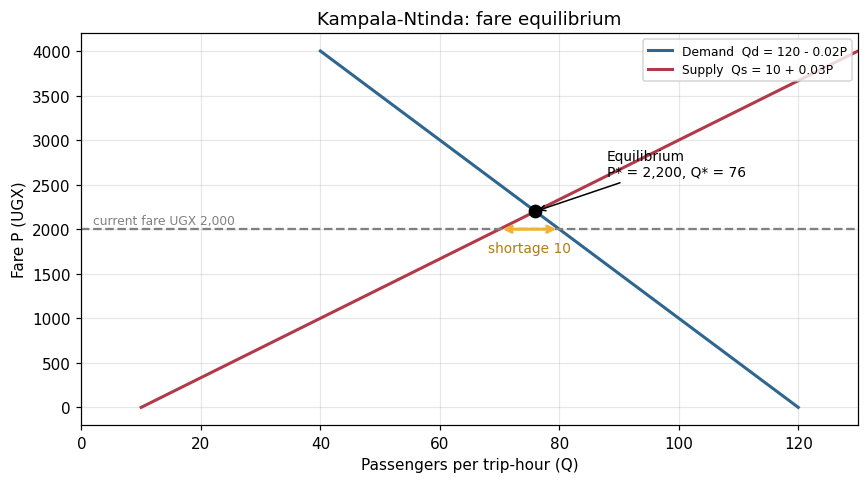

In [5]:
prices = np.linspace(0, 4_000, 200)
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot([market.demand(p) for p in prices], prices, color="#2F6690", lw=2, label="Demand  Qd = 120 - 0.02P")
ax.plot([market.supply(p) for p in prices], prices, color="#B23A48", lw=2, label="Supply  Qs = 10 + 0.03P")
ax.plot(q_star, p_star, "ko", ms=8)
ax.annotate(f"Equilibrium\nP* = {p_star:,.0f}, Q* = {q_star:.0f}", (q_star, p_star), xytext=(q_star + 12, p_star + 400),
            arrowprops=dict(arrowstyle="->"), fontsize=9)
ax.axhline(fare, color="grey", ls="--")
ax.annotate("", xy=(qd, fare), xytext=(qs, fare), arrowprops=dict(arrowstyle="<->", color="#F2B134", lw=2))
ax.text((qd + qs) / 2, fare - 260, f"shortage {qd - qs:.0f}", ha="center", color="#B07D12", fontsize=9)
ax.text(2, fare + 60, f"current fare UGX {fare:,.0f}", fontsize=8, color="grey")
ax.set(xlabel="Passengers per trip-hour (Q)", ylabel="Fare P (UGX)", title="Kampala-Ntinda: fare equilibrium", xlim=(0, 130))
ax.legend(fontsize=8, loc="upper right"); fig.tight_layout(); fig.savefig("figures/p5_equilibrium.png", bbox_inches="tight")
plt.show()

**The current fare (UGX 2,000) is UGX 200 below the equilibrium fare of UGX 2,200.** At 2,000, passengers want 80 seats per trip-hour but operators only offer 70, a **shortage of 10 passengers per trip-hour**. In practice this shows up as queues at the stage, overloading and touts charging informal "peak" surcharges.

Two further points follow:
* Demand is **inelastic** at this fare (elasticity ≈ −0.5): a 10 % fare rise loses only about 5 % of demand. Moving to UGX 2,200 would clear the queue and raise revenue per trip-hour by about **19 %** (from 140,000 on the 70 seats actually supplied to 167,200). The gain comes from both a higher price *and* more vehicles being willing to run.
* The alternative to a fare rise is **more supply at the same fare**, which shifts the supply curve right: more vehicles or faster turnarounds. A regulator or association that wants to keep fares affordable should read the shortage as a signal to add capacity.

**Caveat.** The curve's scale (≈ 76 passengers *per trip-hour*) does not match the observed counts (≈ 47 passengers *per day*), so the two cannot both describe the whole route. I use the curves only for the *direction* of the fare question. The system is also moderately conditioned (κ(A) ≈ 40), simply because $P$ is measured in shillings and $Q$ in passengers; rescaling $P$ to thousands of UGX would reduce κ without changing the answer.

## Task 3 — A `SeriesForecaster` base class and its subclasses

In [6]:
models = [MovingAverage(3), SimpleExponentialSmoothing(0.5), LinearTrend(), NaiveForecaster()]
history = routes[0].passengers
for m in models:
    print(f"{m.label:32s} ({type(m).__name__:26s}) -> day 11 forecast for Ntinda: {m.fit(history).predict():.1f}  "
          f"| is a SeriesForecaster: {isinstance(m, SeriesForecaster)}")

3-day moving average             (MovingAverage             ) -> day 11 forecast for Ntinda: 48.0  | is a SeriesForecaster: True
Exp. smoothing (alpha=0.50)      (SimpleExponentialSmoothing) -> day 11 forecast for Ntinda: 47.2  | is a SeriesForecaster: True
Linear trend                     (LinearTrend               ) -> day 11 forecast for Ntinda: 53.7  | is a SeriesForecaster: True
Naive (last value)               (NaiveForecaster           ) -> day 11 forecast for Ntinda: 45.0  | is a SeriesForecaster: True


Each subclass implements only `_forecast(history)`. `fit()` validates the input and enforces a minimum history (3 days for the moving average, 2 for a trend), and `predict()` refuses to run before `fit()` and never returns a negative passenger count. Those rules are written once, in the base class. The `NaiveForecaster` ("tomorrow = today") is a **benchmark**: a forecasting method is only worth using if it beats it. `SeasonalNaive` is used in the extension.

## Task 4 — Walk-forward backtest over days 4–10, and α grid search

In [7]:
bt = Backtester(first_target=3)     # 0-based index 3 = day 4
alpha_grid = np.round(np.arange(0.05, 1.0001, 0.05), 2)
best_alpha, alpha_scores, results = {}, {}, {}
for r in routes:
    best_alpha[r.name], alpha_scores[r.name] = bt.tune_alpha(r.passengers, alpha_grid)
    candidates = [MovingAverage(3), SimpleExponentialSmoothing(best_alpha[r.name]), LinearTrend(), NaiveForecaster()]
    results[r.name] = bt.compare(candidates, r.passengers)

mae_table = pd.DataFrame({name: {res.label.replace(f"(alpha={best_alpha[name]:.2f})", "(tuned α)"): res.mae for res in rs}
                          for name, rs in results.items()}).T
mae_table["tuned α"] = pd.Series(best_alpha)
mae_table.index.name = "MAE (passengers/day)"
mae_table

,3-day moving average,Exp. smoothing (tuned α),Linear trend,Naive (last value),tuned α
MAE (passengers/day),,,,,
Kampala-Ntinda,7.52,5.86,7.87,5.86,1.00
Kampala-Entebbe,7.19,4.43,7.71,4.43,1.00
Kampala-Mukono,5.33,3.71,6.39,3.71,1.00


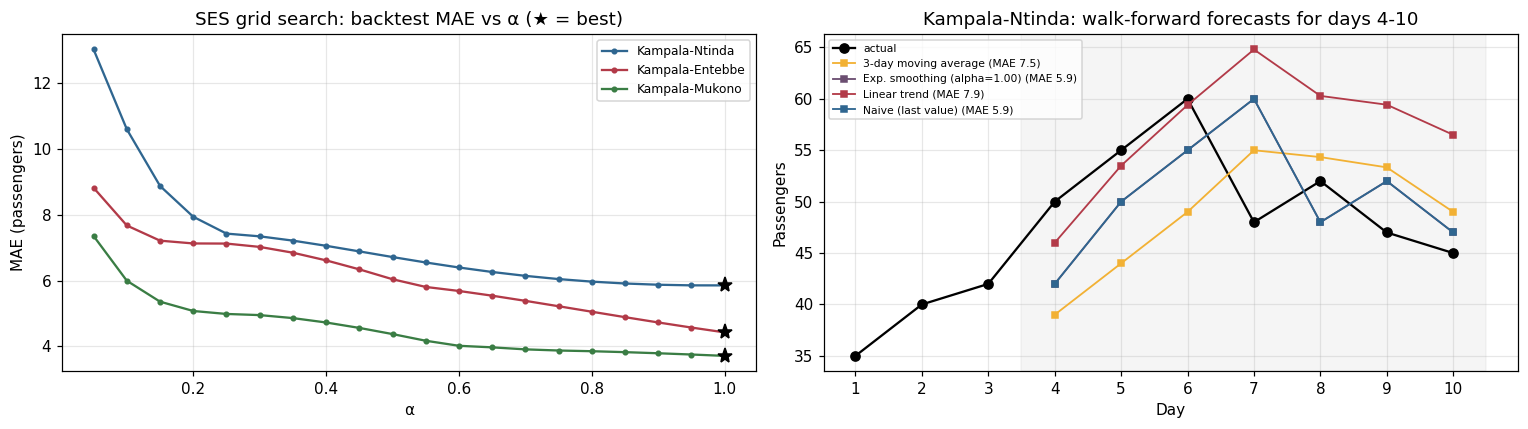

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for name, scores in alpha_scores.items():
    axes[0].plot(list(scores), list(scores.values()), marker="o", ms=3, color=COLORS[name], label=name)
    axes[0].plot(best_alpha[name], scores[best_alpha[name]], "k*", ms=10)
axes[0].set(title="SES grid search: backtest MAE vs α (★ = best)", xlabel="α", ylabel="MAE (passengers)")
axes[0].legend(fontsize=8)

ntinda_res = {res.label: res for res in results["Kampala-Ntinda"]}
axes[1].plot(DAYS, routes[0].passengers, "ko-", label="actual")
for (label, res), c in zip(ntinda_res.items(), ["#F2B134", "#6B4E71", "#B23A48", "#2F6690"]):
    axes[1].plot(res.target_index + 1, res.forecasts, marker="s", ms=4, lw=1.2, color=c, label=f"{label} (MAE {res.mae:.1f})")
axes[1].axvspan(3.5, 10.5, color="grey", alpha=0.08)
axes[1].set(title="Kampala-Ntinda: walk-forward forecasts for days 4-10", xlabel="Day", ylabel="Passengers", xticks=DAYS)
axes[1].legend(fontsize=7)
fig.tight_layout(); fig.savefig("figures/p5_backtest.png", bbox_inches="tight")
plt.show()

**Result: on every route the tuned α is 1.0, which makes exponential smoothing *identical* to the naive forecast.** Nothing more sophisticated beats "tomorrow = today". The 3-day moving average (the original method) is 30–60 % worse than naive, and the linear trend is worst on every route.

**Why.** Each series climbs for five days, peaks on day 6 and then drifts down. Consecutive days are strongly related, but there is no stable trend or mean to revert to. For a series like this, the latest value is the best available information. Averaging over three days (MA) or heavy smoothing (low α) adds *lag*: the forecast chases the peak after it has passed, as the chart shows. A trend line fitted to the rising first half keeps predicting growth after demand has turned.

**Caution.** α was tuned on the same seven days used to report MAE, so the "tuned SES" score is slightly optimistic. Here that makes no practical difference, because it simply reproduces the naive benchmark.

## Task 5 — Day-11 revenue forecast with the best model

In [9]:
rows, best_model = [], {}
for r in routes:
    ranked = sorted(results[r.name], key=lambda res: res.mae)
    winner = ranked[0]
    model = SimpleExponentialSmoothing(best_alpha[r.name])          # tuned α = 1.0 (same as naive)
    pax11 = model.fit(r.passengers).predict()
    best_model[r.name] = model
    rows.append({"route": r.name, "best model": f"SES α={best_alpha[r.name]:.2f} (= naive)", "backtest MAE (pax)": winner.mae,
                 "day-11 passengers": pax11, "fare (UGX)": r.fare, "day-11 revenue (UGX)": pax11 * r.fare,
                 "± MAE in UGX": winner.mae * r.fare,
                 "3-day MA would say (UGX)": MovingAverage(3).fit(r.passengers).predict() * r.fare})
day11 = pd.DataFrame(rows).set_index("route")
day11.loc["All routes", ["day-11 revenue (UGX)", "3-day MA would say (UGX)"]] = day11[["day-11 revenue (UGX)", "3-day MA would say (UGX)"]].sum()
day11

,best model,backtest MAE (pax),day-11 passengers,fare (UGX),day-11 revenue (UGX),± MAE in UGX,3-day MA would say (UGX)
route,,,,,,,
Kampala-Ntinda,SES α=1.00 (= naive),5.86,45.00,"2,000.00","90,000.00","11,714.29","96,000.00"
Kampala-Entebbe,SES α=1.00 (= naive),4.43,64.00,"5,000.00","320,000.00","22,142.86","330,000.00"
Kampala-Mukono,SES α=1.00 (= naive),3.71,50.00,"3,000.00","150,000.00","11,142.86","154,000.00"
All routes,NaN,NaN,NaN,NaN,"560,000.00",NaN,"580,000.00"


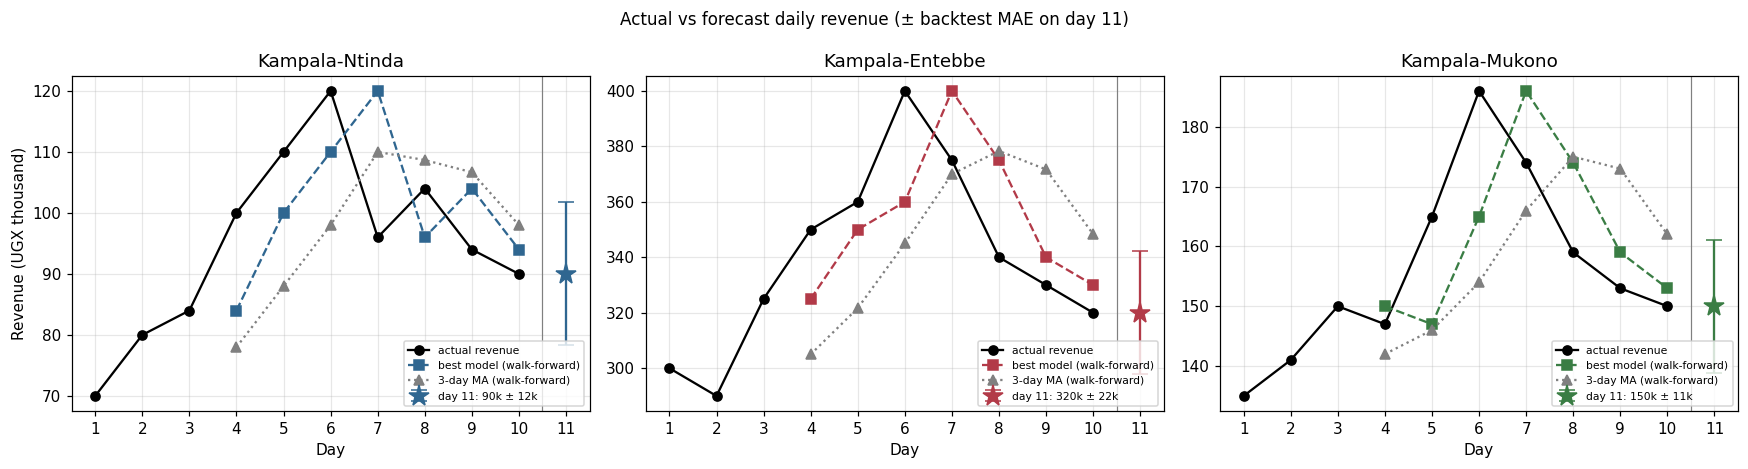

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.3), sharex=True)
for ax, r in zip(axes, routes):
    res = {x.label: x for x in results[r.name]}
    best = min(results[r.name], key=lambda x: x.mae)
    ma = res["3-day moving average"]
    ax.plot(DAYS, r.daily_revenue() / 1e3, "ko-", label="actual revenue")
    ax.plot(best.target_index + 1, best.forecasts * r.fare / 1e3, "s--", color=COLORS[r.name], label="best model (walk-forward)")
    ax.plot(ma.target_index + 1, ma.forecasts * r.fare / 1e3, "^:", color="grey", label="3-day MA (walk-forward)")
    f11 = day11.loc[r.name, "day-11 revenue (UGX)"] / 1e3
    err = day11.loc[r.name, "± MAE in UGX"] / 1e3
    ax.errorbar(11, f11, yerr=err, fmt="*", ms=14, color=COLORS[r.name], capsize=5, label=f"day 11: {f11:,.0f}k ± {err:,.0f}k")
    ax.axvline(10.5, color="grey", lw=0.8)
    ax.set(title=r.name, xlabel="Day", xticks=np.arange(1, 12))
    ax.legend(fontsize=7, loc="lower right")
axes[0].set_ylabel("Revenue (UGX thousand)")
fig.suptitle("Actual vs forecast daily revenue (± backtest MAE on day 11)", fontsize=11)
fig.tight_layout(); fig.savefig("figures/p5_revenue_forecast.png", bbox_inches="tight")
plt.show()

Day-11 forecasts: **Ntinda UGX 90,000, Entebbe UGX 320,000 and Mukono UGX 150,000**, a total of about **UGX 560,000**. The error bars use the backtest MAE (≈ ±12k, ±22k and ±11k UGX). The moving average would forecast about UGX 20,000 more in total, because it still carries the day-6 to day-8 peak.

## Task 6 — Fleet planning for day 11

In [11]:
planner = FleetPlanner(seats=14, trips_per_day=8, buffer=0.15)
directional = FleetPlanner(seats=14, trips_per_day=4, buffer=0.15)   # only the 4 peak-direction trips count
rows = []
for r in routes:
    pax = day11.loc[r.name, "day-11 passengers"]
    upper = pax + day11.loc[r.name, "backtest MAE (pax)"]
    v = planner.vehicles(pax)
    rows.append({
        "route": r.name, "forecast pax": pax, "with 15% buffer": pax * 1.15,
        "raw need (vehicles)": pax * 1.15 / planner.daily_capacity,
        "vehicles (8 trips, round up)": v, "load factor": planner.load_factor(pax, v),
        "vehicles if demand = forecast + MAE": planner.vehicles(upper),
        "vehicles if all demand is one-directional": directional.vehicles(pax),
    })
fleet = pd.DataFrame(rows).set_index("route")
print(f"One vehicle carries {planner.seats} x {planner.trips_per_day} = {planner.daily_capacity} passenger-places per day.")
fleet

One vehicle carries 14 x 8 = 112 passenger-places per day.


,forecast pax,with 15% buffer,raw need (vehicles),"vehicles (8 trips, round up)",load factor,vehicles if demand = forecast + MAE,vehicles if all demand is one-directional
route,,,,,,,
Kampala-Ntinda,45.00,51.75,0.46,1,0.40,1,1
Kampala-Entebbe,64.00,73.60,0.66,1,0.57,1,2
Kampala-Mukono,50.00,57.50,0.51,1,0.45,1,2


**Recommendation: one vehicle per route on day 11**, three in total. Even with the 15 % buffer, the largest route (Entebbe, ≈ 74 passengers) needs only 0.66 of a vehicle's daily capacity. Rounding is always **up**, since a fraction of a vehicle cannot run and rounding down would strand passengers. The minimum is also one vehicle, so that a route is never left without service.

"Round sensibly" also means checking the assumptions behind the capacity figure:
* **Direction.** Eight one-way trips are four out and four back. If most passengers travel *into* town in the morning and *out* in the evening, only about half the seats are usable. Treating only the four peak-direction trips as useful capacity (56 places), **Entebbe and Mukono each need a second vehicle** (73.6 and 57.5 buffered passengers), while Ntinda stays at one.
* **Load factor.** One vehicle each gives 40–57 % seat occupancy, which is healthy for matatu economics, since many operators aim to depart full. A second vehicle would halve occupancy, so on Entebbe and Mukono it is best treated as a *standby* for the peak direction rather than a full-day deployment.
* **The equilibrium model disagrees.** It implies 70–80 passengers per *trip-hour* on Ntinda alone. If that is closer to reality, the observed counts are a sample (for example, a single stage or vehicle), and fleet needs would be many times larger. The association should reconcile the two data sources before buying vehicles.

## Extension — 60 days with a weekly pattern: seasonal naive vs moving average

I simulate 60 days per route (seeded) with a weekly multiplier: Mon 1.00, Tue 0.95, Wed 0.97, Thu 1.02, **Fri 1.30**, Sat 1.10, **Sun 0.65**, and 6 % Gaussian noise, around each route's observed mean. Day 1 is a Monday. The walk-forward test starts on day 15, so that every model, including the 7-day seasonal naive, has two full weeks of history. That gives 46 one-step forecasts per model per route.

In [12]:
bt60 = Backtester(first_target=14)
sim, sim_results, rows = {}, {}, []
for k, r in enumerate(routes):
    y = simulate_weekly_demand(base=r.passengers.mean(), n_days=60, seed=SEED + k)
    sim[r.name] = y
    a, _ = bt60.tune_alpha(y)
    res = bt60.compare([MovingAverage(3), SimpleExponentialSmoothing(a), LinearTrend(), NaiveForecaster(), SeasonalNaive(7)], y)
    sim_results[r.name] = res
    abs_err = {x.label: np.abs(x.errors) for x in res}
    ma_err, sn_err = abs_err["3-day moving average"], abs_err["Seasonal naive (period 7)"]
    w = stats.wilcoxon(ma_err, sn_err, alternative="greater")
    row = {x.label.split(" (alpha")[0] + (" (tuned α)" if "alpha" in x.label else ""): x.mae for x in res}
    row.update({"route": r.name, "MA3 / seasonal-naive MAE": ma_err.mean() / sn_err.mean(),
                "days seasonal naive better": np.mean(sn_err < ma_err), "Wilcoxon p (MA3 worse)": f"{w.pvalue:.2g}"})
    rows.append(row)
ext = pd.DataFrame(rows).set_index("route")
ext

,3-day moving average,Exp. smoothing (tuned α),Linear trend,Naive (last value),Seasonal naive (period 7),MA3 / seasonal-naive MAE,days seasonal naive better,Wilcoxon p (MA3 worse)
route,,,,,,,,
Kampala-Ntinda,8.14,6.51,6.65,10.70,2.85,2.86,0.76,3e-05
Kampala-Entebbe,10.02,8.68,9.07,13.63,4.87,2.06,0.65,0.0031
Kampala-Mukono,7.80,6.51,6.64,10.39,4.39,1.78,0.61,0.014


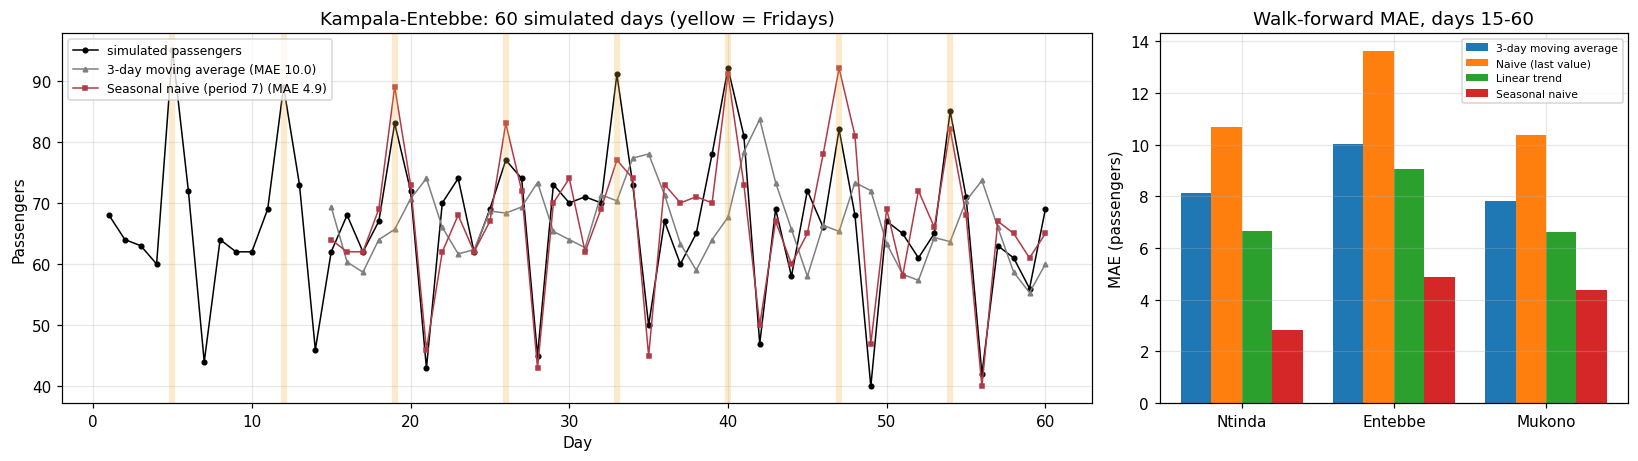

In [13]:
name = "Kampala-Entebbe"
y = sim[name]
res = {x.label: x for x in sim_results[name]}
fig, axes = plt.subplots(1, 2, figsize=(15, 4.3), gridspec_kw={"width_ratios": [2.2, 1]})
ax = axes[0]
days60 = np.arange(1, 61)
ax.plot(days60, y, "k-", lw=1, marker="o", ms=3, label="simulated passengers")
for label, c, mk in [("3-day moving average", "grey", "^"), ("Seasonal naive (period 7)", COLORS[name], "s")]:
    ax.plot(res[label].target_index + 1, res[label].forecasts, color=c, marker=mk, ms=3, lw=1, label=f"{label} (MAE {res[label].mae:.1f})")
for d in days60[(days60 - 1) % 7 == 4]:
    ax.axvline(d, color="#F2B134", alpha=0.25, lw=4)
ax.set(title=f"{name}: 60 simulated days (yellow = Fridays)", xlabel="Day", ylabel="Passengers")
ax.legend(fontsize=8, loc="upper left")

ax = axes[1]
labels = ["3-day moving average", "Naive (last value)", "Linear trend", "Seasonal naive (period 7)"]
x = np.arange(len(routes))
width = 0.2
for i, lab in enumerate(labels):
    ax.bar(x + (i - 1.5) * width, [np.mean(np.abs({r.label: r for r in sim_results[rt.name]}[lab].errors)) for rt in routes],
           width, label=lab.replace(" (period 7)", ""))
ax.set_xticks(x, [r.name.replace("Kampala-", "") for r in routes])
ax.set(title="Walk-forward MAE, days 15-60", ylabel="MAE (passengers)")
ax.legend(fontsize=7)
fig.tight_layout(); fig.savefig("figures/p5_seasonal_extension.png", bbox_inches="tight")
plt.show()

**Seasonal naive wins clearly on every route.** Its MAE is **between a half and a third** of the 3-day moving average's (ratio 1.8–2.9). A one-sided Wilcoxon signed-rank test on the paired absolute errors rejects "MA3 is no worse" at the 5 % level on all three routes (p ≈ 0.00003, 0.003 and 0.014).

The moving average's errors cluster on Fridays and Sundays. After a quiet Sunday it under-forecasts Monday; on Friday it averages Tuesday–Thursday and misses the surge; and it then carries Friday's surge into its Sunday forecast. Seasonal naive copies last Friday for this Friday, so it is only wrong by the random noise and any drift. The naive forecast that won on the 10-day data now does *worst*: tomorrow is no longer like today, so the last value carries yesterday's weekday effect into the wrong day.

**Lesson: the best model depends on the data's structure.** With 10 days the weekly pattern could not even be seen. With 60 days, a forecaster that knows about weeks beats any amount of smoothing.

## Findings & Limitations

**Findings.** Entebbe carries 57 % of the association's revenue from about 40 % of its passengers, so fare level matters as much as ridership. On Ntinda, the stated demand and supply curves put the equilibrium fare at UGX 2,200: the current UGX 2,000 is below it, leaving a shortage of 10 passengers per trip-hour. Because demand is inelastic there (elasticity −0.5), clearing that shortage with a fare rise would raise revenue per trip-hour by about 19 %; adding vehicles would clear it without a rise. In forecasting, the honest benchmark mattered most. Walk-forward testing over days 4–10 showed that the original 3-day moving average was 30–60 % worse than simply repeating yesterday. The α grid search confirmed this by selecting α = 1, which *is* the naive forecast. The series behave like random walks, and smoothing only adds lag. Day-11 revenue is therefore forecast at about UGX 560,000. Fleet needs are small: one vehicle per route covers the forecast plus a 15 % buffer at 40–57 % seat occupancy. Entebbe and Mukono need a standby second vehicle if demand is strongly one-directional. When a weekly pattern exists, as in the 60-day simulation, a seasonal naive forecaster halves the moving average's error, and the difference is statistically significant.

**Limitations.** Ten days is far too short to estimate seasonality or to separate models with confidence, and the α tuning reuses the evaluation window. The demand and supply curves are given rather than estimated, and their scale conflicts with the observed counts. Fleet sizing assumes full-capacity trips, fixed trip counts and no traffic delays, breakdowns or boarding at intermediate stages. The 60-day data are simulated from an assumed weekly pattern, so the extension shows *that* a seasonal model helps when seasonality exists, not *how much* seasonality real routes have.